# Module 07 - Self-Attention

This notebook is for making the attention mechanism concrete after the package tests pass. The goal is not to build a polished language model yet. The goal is to see queries, keys, values, masks, attention weights, and the quadratic cost in live tensors.

1. Read the lesson page (`docs/modules/07-attention.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 07`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [ ]:
from __future__ import annotations

import math
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.attention import SelfAttention
from g2c.embeddings import LearnedPositionalEmbedding, TokenEmbedding
from g2c.nn import CrossEntropyLoss, Linear, Module, SGD, resolve_device
from g2c.notebook_extras.attention import (
    plot_random_sentence_attention,
    plot_trained_shakespeare_attention_heads,
    run_tinyshakespeare_attention_probe,
)

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
experiment_device = "auto"
print("MPS available:", torch.backends.mps.is_available())


## Before the Notebook

Implement `SelfAttention.forward` and `SelfAttention.attention_weights` first. The notebook assumes the Module 07 tests are green, because the experiments below call those public methods directly.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_attention.py -x"
"Question: Which attention test is the next one failing, and what implementation detail does it point at?"
"Answer: "

'Answer: '

In [3]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_attention.py"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Module 07 attention tests are not passing yet."
print("Module 07 attention tests passed.")

.......................                                                  [100%]
23 passed in 0.53s

Module 07 attention tests passed.


## Exercise 1 - A Three-Token Attention Pass by Hand

Start with one batch, three positions, and two channels. Before running the check cell, write down the expected shapes of Q, K, V, scores, weights, and output. Then compare the manual tensor pipeline to `SelfAttention.forward`.

In [4]:
"Question: For x shaped (1, 3, 2), what shape should Q @ K.T have?"
"Answer: "

"Question: Which dimension should softmax normalize over, and why?"
"Answer: "

"Question: Why does causal=False make this hand check easier?"
"Answer: "

'Answer: '

In [5]:
toy_x = torch.tensor([[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]])
toy_attn = SelfAttention(embedding_dim=2, causal=False)

q = toy_attn.q_proj(toy_x)
k = toy_attn.k_proj(toy_x)
v = toy_attn.v_proj(toy_x)
scores = q @ k.transpose(-2, -1) / math.sqrt(toy_attn.embedding_dim)
weights = scores.softmax(dim=-1)
manual_out = toy_attn.out_proj(weights @ v)
module_out = toy_attn(toy_x)

print("q shape:", tuple(q.shape))
print("scores shape:", tuple(scores.shape))
print("attention weights:")
print(weights[0].detach())
print("max absolute diff:", (manual_out - module_out).abs().max().item())

assert torch.allclose(manual_out, module_out, atol=1e-5)

q shape: (1, 3, 2)
scores shape: (1, 3, 3)
attention weights:
tensor([[0.3062, 0.3379, 0.3559],
        [0.3842, 0.3014, 0.3144],
        [0.3550, 0.3073, 0.3377]])
max absolute diff: 0.0


## Exercise 2 - Visualize Attention on Two Sentences

These weights are from an untrained random attention layer, so this is a **negative control**. You should not see a semantic pattern yet. The point is to make the visualization plumbing real: tokenize, embed, add position, call `attention_weights`, and plot the `(T, T)` matrix.

If the reusable `G2CTokenizer` artifact exists, this exercise uses that corpus-trained tokenizer with effective vocab size 2048. If it is missing, the cell falls back to a simple character tokenizer. The raw probability heatmap uses a fixed color scale so a nearly-uniform random layer does not get visually exaggerated. The second row subtracts the uniform baseline `1 / T`, which makes tiny random deviations visible without implying the model understands the sentence.


In [6]:
"Question: Why should random attention weights not resolve what 'it' refers to yet?"
"Answer: "

"Question: What would you hope to see after training on enough text?"
"Answer: "

'Answer: '

In [ ]:
attention_sentences = [
    "the animal did not cross the street because it was too tired",
    "the animal did not cross the street because it was too wide",
]

plot_random_sentence_attention(
    attention_sentences,
    repo_root=repo_root,
    tokenizer_name="G2CTokenizer",
    vocab_size=2048,
)


## Optional Probe - Train Attention on TinyShakespeare

The random sentence heatmap is a negative control. This optional probe gives you a positive control without waiting for the full Module 10 milestone: train a tiny causal attention model on TinyShakespeare for a short run, then compare the same model's attention before and after training.

If the reusable `ShakespeareTokenizer` exists, the probe uses it at effective vocab size 2048 and caps the training stream at 1,000,000 tokens. If the artifact is missing, it falls back to a character tokenizer. This is still not semantic interpretability. We are looking for a simpler fact: training should make attention sharper and less like the causal-uniform baseline.


In [8]:
"Question: What changes between the before-training and after-training attention maps?"
"Answer: "

"Question: Why is sharper trained attention still not the same thing as semantic understanding?"
"Answer: "

'Answer: '

In [ ]:
probe_model = run_tinyshakespeare_attention_probe(
    repo_root=repo_root,
    device=experiment_device,
    steps=600,
    batch_size=128,
    lr=3e-3,
    log_every=100,
)


## Optional Revisit - Inspect a Trained ShakespeareLM Head

After Module 10 has saved `ShakespeareLM`, you can come back and run a short forward pass through the trained model. This is the same heatmap plumbing as Exercise 2, but now the weights come from a model that has actually trained on TinyShakespeare.

This is optional and safely skips if no artifact exists yet. Do not expect clean human-readable explanations from one tiny trained head. The useful question is narrower: did training move attention away from the random near-uniform baseline?

In [11]:
"Question: Why is a trained ShakespeareLM attention map still not proof that the model understands a sentence semantically?"
"Answer: "

"Question: Why does this optional revisit belong after Module 10 rather than on the first Module 07 pass?"
"Answer: "

'Answer: '

In [ ]:
plot_trained_shakespeare_attention_heads(repo_root=repo_root)


## Exercise 3 - The Strip-Mask Cheat

This experiment uses a sequence-wide language-modeling objective: input positions `0..T-1` predict targets `1..T`. With `causal=False`, position `t` can attend to input position `t+1`, which is exactly the target for that row. With `causal=True`, it cannot. The loss below ignores the final position because its target is outside the input window in both settings; the point is to isolate the rows where future-token leakage exists.

That leakage does **not** show up with Module 06's `train_lm` last-position interface, because the target token is outside the input window. The all-positions setup below is the standard transformer LM training shape where the causal mask is load-bearing.

In [22]:
"Question: Why does the non-causal model have access to the answer in this setup?"
"Answer: "

"Question: Why would a suspiciously perfect training curve be a red flag in an LM?"
"Answer: "

'Answer: '

In [23]:
class TinySequenceAttentionLM(Module):
    def __init__(self, vocab_size: int, seq_len: int, embedding_dim: int, *, causal: bool) -> None:
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        self.embed = TokenEmbedding(vocab_size, embedding_dim)
        self.pos = LearnedPositionalEmbedding(seq_len, embedding_dim)
        self.attn = SelfAttention(embedding_dim, causal=causal)
        self.out = Linear(embedding_dim, vocab_size)

    def parameters(self):
        return [
            *self.embed.parameters(),
            *self.pos.parameters(),
            *self.attn.parameters(),
            *self.out.parameters(),
        ]

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        B, T = ids.shape
        x = self.embed(ids) + self.pos(T).unsqueeze(0)
        x = self.attn(x)
        return self.out(x)


def get_sequence_batch(ids: torch.Tensor, seq_len: int, batch_size: int, *, generator=None):
    starts = torch.randint(0, len(ids) - seq_len - 1, (batch_size,), generator=generator)
    x = torch.stack([ids[s : s + seq_len] for s in starts])
    y = torch.stack([ids[s + 1 : s + seq_len + 1] for s in starts])
    return x, y


def sequence_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    # Ignore the last row: its target is not present in the input window.
    logits = logits[:, :-1, :]
    targets = targets[:, :-1]
    return CrossEntropyLoss()(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))


def train_sequence_model(model, ids, *, steps=500, batch_size=128, lr=0.5, log_every=50, seed=0, device=experiment_device):
    device = resolve_device(device)
    model.to(device)
    optimizer = SGD(model.parameters(), lr=lr)
    losses = []
    generator = torch.Generator().manual_seed(seed)
    for step in range(steps):
        x, y = get_sequence_batch(ids, model.seq_len, batch_size, generator=generator)
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = sequence_loss(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % log_every == 0 or step == steps - 1:
            losses.append(float(loss.item()))
    return losses

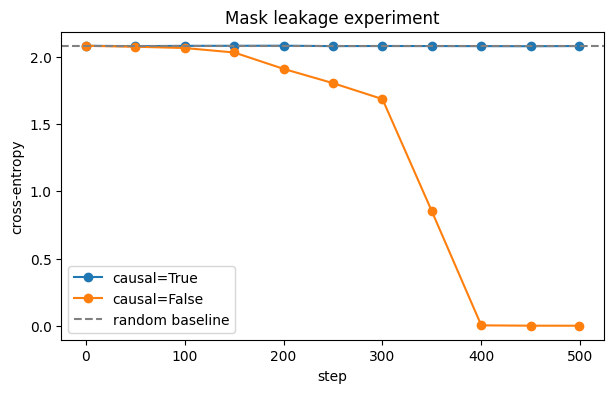

final causal loss: 2.0776398181915283
final non-causal loss: 0.000925648957490921


In [24]:
random_vocab_size = 8
random_stream = torch.randint(
    0,
    random_vocab_size,
    (4096,),
    generator=torch.Generator().manual_seed(7),
)

strip_seq_len = 8
strip_steps = 500
strip_log_every = 50

causal_lm = TinySequenceAttentionLM(random_vocab_size, strip_seq_len, 32, causal=True)
noncausal_lm = TinySequenceAttentionLM(random_vocab_size, strip_seq_len, 32, causal=False)

causal_losses = train_sequence_model(
    causal_lm,
    random_stream,
    steps=strip_steps,
    log_every=strip_log_every,
    seed=1,
)
noncausal_losses = train_sequence_model(
    noncausal_lm,
    random_stream,
    steps=strip_steps,
    log_every=strip_log_every,
    seed=2,
)

strip_steps_logged = list(range(0, strip_steps, strip_log_every))
if strip_steps_logged[-1] != strip_steps - 1:
    strip_steps_logged.append(strip_steps - 1)

plt.figure(figsize=(7, 4))
plt.plot(strip_steps_logged, causal_losses, marker="o", label="causal=True")
plt.plot(strip_steps_logged, noncausal_losses, marker="o", label="causal=False")
plt.axhline(math.log(random_vocab_size), color="0.5", linestyle="--", label="random baseline")
plt.title("Mask leakage experiment")
plt.xlabel("step")
plt.ylabel("cross-entropy")
plt.legend()
plt.show()

print("final causal loss:", causal_losses[-1])
print("final non-causal loss:", noncausal_losses[-1])

## Exercise 4 - Parameter Count

The attention layer has four `Linear(D, D)` projections: Q, K, V, and output. That means the parameter count is `4 * (D * D + D)` and does not depend on sequence length.

In [25]:
"Question: Why does the parameter count not depend on T?"
"Answer: "

"Question: If parameters do not grow with T, what part of attention still gets expensive as T grows?"
"Answer: "

'Answer: '

In [26]:
print("D    expected    actual")
print("-" * 28)
for D in [64, 128, 256, 512]:
    attn = SelfAttention(embedding_dim=D)
    expected = 4 * (D * D + D)
    actual = sum(p.numel() for p in attn.parameters())
    print(f"{D:<4d} {expected:<10d} {actual:<10d}")
    assert expected == actual

D    expected    actual
----------------------------
64   16640      16640     
128  66048      66048     
256  263168     263168    
512  1050624    1050624   


## Exercise 5 - Feel the Quadratic Cost

The score tensor is shaped `(B, T, T)`. This timing cell keeps `D` fixed and increases `T`. The default sizes are conservative for a notebook; add larger values if your machine is comfortable.

In [ ]:
"Question: Why should a log-log time plot bend toward slope 2 as T grows?"
"Answer: "

"Question: Why might small T values not show a clean quadratic trend?"
"Answer: "

In [ ]:
timing_attn = SelfAttention(embedding_dim=128, causal=True)
timing_lengths = [64, 128, 256, 512]
timing_seconds = []

for T in timing_lengths:
    x = torch.randn(1, T, 128)
    _ = timing_attn(x)
    start = time.perf_counter()
    with torch.no_grad():
        _ = timing_attn(x)
    elapsed = time.perf_counter() - start
    timing_seconds.append(elapsed)
    print(f"T={T:<5d} seconds={elapsed:.5f}")

plt.figure(figsize=(6, 4))
plt.loglog(timing_lengths, timing_seconds, marker="o")
plt.title("Self-attention wall time vs sequence length")
plt.xlabel("sequence length T")
plt.ylabel("seconds")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()